In [2]:
!pip install --upgrade --force-reinstall --no-cache-dir \
numpy==1.26.4 \
scipy==1.13.1 \
albumentations==1.4.7 \
opencv-python==4.10.0.84 \
Pillow==10.4.0 \
tqdm==4.66.5 
!pip install torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 --index-url https://download.pytorch.org/whl/cu121
!pip install segmentation-models-pytorch==0.3.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 271.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 267.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 58.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 275.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 287.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 325.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 327.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 347.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 308.5 MB/s eta 0:00:00
   ━━━━━━━━━

In [6]:

import numpy as np
import matplotlib.pyplot as plt


In [7]:
import torch

import segmentation_models_pytorch as smp
from PIL import Image
import albumentations as A


In [8]:
import torch, torchvision
import albumentations as A
import segmentation_models_pytorch as smp
import scipy, matplotlib, cv2
print(
    "torch:", torch.__version__,
    "\ntorchvision:", torchvision.__version__,
    "\nSMP:", smp.__version__,
    "\nalbumentations:", A.__version__,
    "\nnumpy:", np.__version__,
    "\nscipy:", scipy.__version__,
)



torch: 2.3.1+cu121 
torchvision: 0.18.1+cu121 
SMP: 0.3.4 
albumentations: 1.4.7 
numpy: 1.26.4 
scipy: 1.13.1


In [9]:
from PIL import Image
from albumentations.pytorch import ToTensorV2

In [10]:
from glob import glob
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import os

In [11]:
class LandcoverDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_paths = sorted(glob(os.path.join(image_dir, "*.png")))
        self.mask_paths = sorted(glob(os.path.join(mask_dir, "*.png")))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        mask = np.array(Image.open(self.mask_paths[idx]).convert("RGB"))

        # Scale mask up to 0-255 range if max < 10
        if mask.max() <= 8:
            mask = (mask.astype(np.float32) * (255/8)).astype(np.uint8)

        # Convert mask to single-channel class indices (optional if multi-class)
        # Here assuming each RGB triplet corresponds to a class
        mask = mask[...,0] // 32  # if RGB values 0-255, gives 8 classes

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']

        return img, mask.long()

In [13]:
from albumentations.pytorch import ToTensorV2
preprocess_input = smp.encoders.get_preprocessing_fn('resnet50', pretrained='imagenet')
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=preprocess_input.keywords['mean'], std=preprocess_input.keywords['std']),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=preprocess_input.keywords['mean'], std=preprocess_input.keywords['std']),
    ToTensorV2()
])

In [14]:
train_dataset = LandcoverDataset("/kaggle/input/landcover-images/landcover_images/train/images",
                                 "/kaggle/input/landcover-images/landcover_images/train/masks",
                                 transform=train_transform)

val_dataset = LandcoverDataset("/kaggle/input/landcover-images/landcover_images/validation/images",
                               "/kaggle/input/landcover-images/landcover_images/validation/masks",
                               transform=val_transform)

test_dataset = LandcoverDataset("/kaggle/input/landcover-images/landcover_images/test/images",
                                "/kaggle/input/landcover-images/landcover_images/test/masks",
                                transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,num_workers = 2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers = 2)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=9  # number of landcover classes
)
model.to(DEVICE)

In [ ]:
from tqdm import tqdm

# Path to your training masks folder
mask_dir = "/kaggle/input/landcover-images/landcover_images/train/masks"  # <-- change if needed

# Count total pixels per class
num_classes = 9  # adjust to your dataset
class_counts = np.zeros(num_classes, dtype=np.int64)

print("Scanning masks to compute class frequencies...")

for mask_name in tqdm(os.listdir(mask_dir)):
    if not mask_name.endswith(".png"):
        continue
    mask_path = os.path.join(mask_dir, mask_name)
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    if mask is None:
        continue
    unique, counts = np.unique(mask, return_counts=True)
    for u, c in zip(unique, counts):
        if u < num_classes:
            class_counts[u] += c

print(f"Class pixel counts: {class_counts}")

# Compute inverse-frequency weights
# Add epsilon to avoid division by zero
epsilon = 1e-6
class_weights = 1.0 / (class_counts + epsilon)
class_weights = class_weights / class_weights.sum()  # normalize

print(f"Normalized class weights: {class_weights}")

# Convert to PyTorch tensor
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to("cuda" if torch.cuda.is_available() else "cpu")

print(f"Final weights tensor (for CrossEntropyLoss): {weights_tensor}")


In [ ]:
dice_loss = smp.losses.DiceLoss(mode='multiclass')
criterion = torch.nn.CrossEntropyLoss(weight=weights_tensor)
def combined_loss(pred, target):
    ce = criterion(pred, target)
    dice = dice_loss(pred, target)
    return ce + dice

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
def train_model(model, train_loader, val_loader, num_epochs=30, patience=5):
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        print(f"\nEpoch [{epoch+1}/{num_epochs}]")

        # ---------- Training ----------
        model.train()
        running_train_loss = 0.0
        for images, masks in tqdm(train_loader, desc="Training", leave=False):
            images, masks = images.to(DEVICE), masks.to(DEVICE).long()

            optimizer.zero_grad()
            outputs = model(images)
            loss = combined_loss(outputs, masks)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * images.size(0)

        train_loss = running_train_loss / len(train_loader.dataset)

        # ---------- Validation ----------
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc="Validation", leave=False):
                images, masks = images.to(DEVICE), masks.to(DEVICE).long()
                outputs = model(images)
                loss = combined_loss(outputs, masks)
                running_val_loss += loss.item() * images.size(0)

        val_loss = running_val_loss / len(val_loader.dataset)

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # ---------- Early Stopping ----------
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pth")
            print("✅ Best model saved.")
        else:
            patience_counter += 1
            print(f"⏳ Patience counter: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("🛑 Early stopping triggered.")
                break

    print("\nTraining complete.")


In [ ]:
train_model(model, train_loader, val_loader, num_epochs=30, patience=5)

In [ ]:
torch.save(model.state_dict(), "/kaggle/working/resnet_model.pth")
print("✅ Model saved successfully!")

In [ ]:
# ============================
# 🎨 VISUALIZATION CODE
# ============================

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F

# ---- RELOAD BEST MODEL ----
model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=9,
)
model.load_state_dict(torch.load("/kaggle/working/best_model.pth", map_location=DEVICE))
model.to(DEVICE)
model.eval()

# ---- DIRECTORIES ----
test_img_dir = "/kaggle/input/landcover-images/landcover_images/test/images"
test_mask_dir = "/kaggle/input/landcover-images/landcover_images/test/masks"

test_files = sorted(os.listdir(test_img_dir))[:5]

# ---- VISUALIZATION ----
for fname in test_files:
    img_path = os.path.join(test_img_dir, fname)
    mask_path = os.path.join(test_mask_dir, fname)

    # Load original (no transform)
    img = np.array(Image.open(img_path).convert("RGB"))
    mask = np.array(Image.open(mask_path).convert("L"))  # grayscale mask (0–N)

    # Convert to tensor for model
    x = torch.from_numpy(img.transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE) / 255.0

    with torch.no_grad():
        logits = model(x)
        pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)

    # --- Normalize both masks to full 0–255 for display ---
    true_mask_scaled = (mask / mask.max() * 255).astype(np.uint8)
    pred_mask_scaled = (pred / pred.max() * 255).astype(np.uint8)

    # --- Show results ---
    fig, axs = plt.subplots(1, 3, figsize=(15, 6))
    axs[0].imshow(img)
    axs[0].set_title("Original Image")
    axs[0].axis('off')

    axs[1].imshow(true_mask_scaled, cmap="gray")
    axs[1].set_title("Ground Truth (grayscale)")
    axs[1].axis('off')

    axs[2].imshow(pred_mask_scaled, cmap="gray")
    axs[2].set_title("Prediction (grayscale)")
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()


Model loaded successfully from: /kaggle/input/best-model/pytorch/default/1/best_model.pth
Pixels evaluated: 81592320

Confusion Matrix:
 [[ 1643675   134557    67936     6072     2148    43178    30129     3660
         0]
 [  152094 14174016   197696    68834  1135061    31332  1269979   144773
         0]
 [  405059  4642168  5889164  1352318   189424    11175   328909  2102173
         0]
 [   33429   766291   681253  3584167    71847    11254   112090   142384
         0]
 [   10020  4903605    54050    43888  9635104    45029   270222    53749
         0]
 [  126291   288048    25680    15025    30490  2094544    81638    21889
         0]
 [   14920  1250195    30657     8251   110960     5402  9579419     9950
         0]
 [   14295  1302423   986745   108087    86730     4236    34636 10917897
         0]
 [       0        0        0        0        0        0        0        0
         0]]


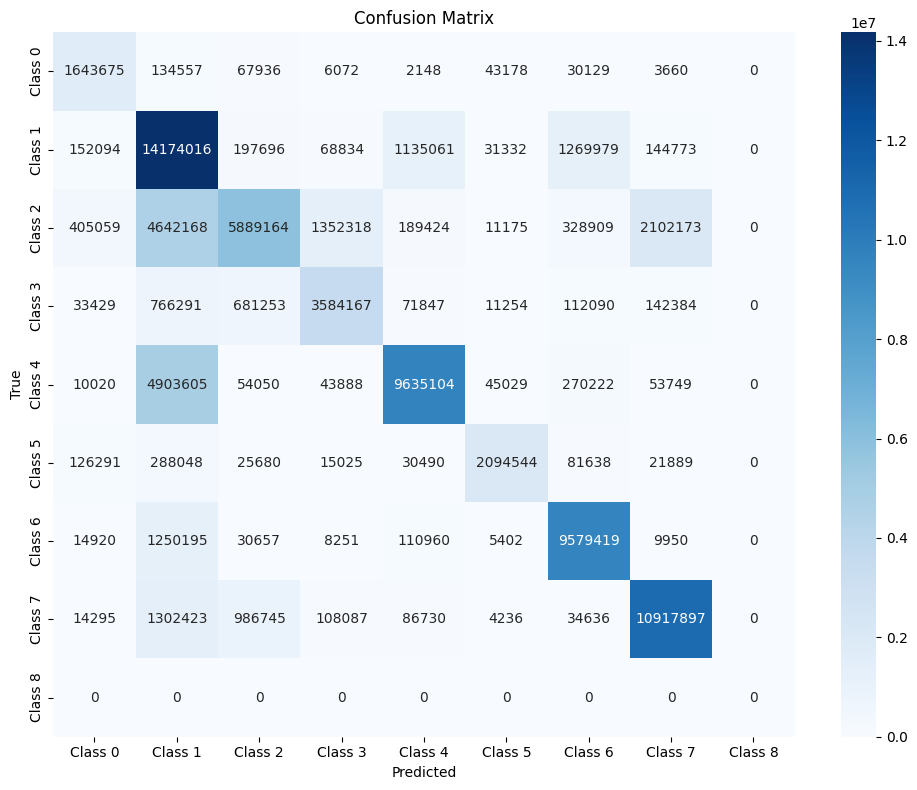


📊 SEGMENTATION METRICS
Overall Accuracy     : 0.7049
Average Accuracy     : 0.6487
Mean IoU (mIoU)      : 0.5186
FWIoU                : 0.5520
Precision (macro)    : 0.6729
Recall (macro)       : 0.6487
F1-score (macro)     : 0.6473
Kappa Coefficient    : 0.6461

📌 PER-CLASS METRICS
--------------------------------------
Class 0:
  IoU         : 0.6116
  Dice        : 0.7590
  Accuracy    : 0.8510
  Precision   : 0.6849
  Recall      : 0.8510
  F1 Score    : 0.7590
--------------------------------------
Class 1:
  IoU         : 0.4653
  Dice        : 0.6351
  Accuracy    : 0.8253
  Precision   : 0.5161
  Recall      : 0.8253
  F1 Score    : 0.6351
--------------------------------------
Class 2:
  IoU         : 0.3471
  Dice        : 0.5154
  Accuracy    : 0.3947
  Precision   : 0.7423
  Recall      : 0.3947
  F1 Score    : 0.5154
--------------------------------------
Class 3:
  IoU         : 0.5116
  Dice        : 0.6769
  Accuracy    : 0.6634
  Precision   : 0.6910
  Recall      : 0

In [15]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------
# 0️⃣ LOAD MODEL FROM KAGGLE INPUT
# ---------------------------------------

MODEL_PATH = "/kaggle/input/best-model/pytorch/default/1/best_model.pth"  # change filename if needed

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 👉 Replace this with your actual architecture
import segmentation_models_pytorch as smp
model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=9
)

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint)
model.to(DEVICE)

print("Model loaded successfully from:", MODEL_PATH)

# ---------------------------------------
# Evaluation
# ---------------------------------------

num_classes = 9
class_names = [f"Class {i}" for i in range(num_classes)]

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)

        all_preds.append(preds.cpu().numpy().reshape(-1))
        all_labels.append(masks.cpu().numpy().reshape(-1))

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)

valid = (y_true >= 0) & (y_true < num_classes)
y_true = y_true[valid]
y_pred = y_pred[valid]

print("Pixels evaluated:", len(y_true))

# ---------------------------------------
# CONFUSION MATRIX
# ---------------------------------------

cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# ---------------------------------------
# IoU, mIoU, FWIoU
# ---------------------------------------

intersection = np.diag(cm)
gt = cm.sum(axis=1)
pred = cm.sum(axis=0)
union = gt + pred - intersection

IoU = intersection / (union + 1e-8)
mIoU = np.nanmean(IoU)

freq = gt / (np.sum(cm) + 1e-8)
FWIoU = (freq * IoU).sum()

# ---------------------------------------
# Accuracy Metrics
# ---------------------------------------

per_class_acc = intersection / (gt + 1e-8)
avg_acc = np.nanmean(per_class_acc)
overall_acc = intersection.sum() / cm.sum()

# ---------------------------------------
# Precision, Recall, F1
# ---------------------------------------

precision_per_class, recall_per_class, f1_per_class, support = \
    precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(num_classes)),
        zero_division=0
    )

precision_macro = precision_per_class.mean()
recall_macro = recall_per_class.mean()
f1_macro = f1_per_class.mean()

# ---------------------------------------
# Cohen’s Kappa
# ---------------------------------------

kappa = cohen_kappa_score(y_true, y_pred)

# ---------------------------------------
# PRINT FINAL METRICS
# ---------------------------------------

print("\n==============================")
print("📊 SEGMENTATION METRICS")
print("==============================")
print(f"Overall Accuracy     : {overall_acc:.4f}")
print(f"Average Accuracy     : {avg_acc:.4f}")
print(f"Mean IoU (mIoU)      : {mIoU:.4f}")
print(f"FWIoU                : {FWIoU:.4f}")
print(f"Precision (macro)    : {precision_macro:.4f}")
print(f"Recall (macro)       : {recall_macro:.4f}")
print(f"F1-score (macro)     : {f1_macro:.4f}")
print(f"Kappa Coefficient    : {kappa:.4f}")
print("==============================\n")

print("📌 PER-CLASS METRICS")
print("--------------------------------------")
for i in range(num_classes):
    dice = (2 * intersection[i]) / (gt[i] + pred[i] + 1e-8)
    print(f"Class {i}:")
    print(f"  IoU         : {IoU[i]:.4f}")
    print(f"  Dice        : {dice:.4f}")
    print(f"  Accuracy    : {per_class_acc[i]:.4f}")
    print(f"  Precision   : {precision_per_class[i]:.4f}")
    print(f"  Recall      : {recall_per_class[i]:.4f}")
    print(f"  F1 Score    : {f1_per_class[i]:.4f}")
    print("--------------------------------------")


In [ ]:
import torch
import numpy as np

def compute_iou_dice(preds, targets, num_classes):
    """
    preds, targets: torch tensors of shape (N, H, W)
    num_classes: total number of segmentation classes
    """
    iou_list = []
    dice_list = []

    preds = preds.cpu().numpy()
    targets = targets.cpu().numpy()

    for cls in range(num_classes):
        pred_inds = (preds == cls)
        target_inds = (targets == cls)

        intersection = np.logical_and(pred_inds, target_inds).sum()
        union = np.logical_or(pred_inds, target_inds).sum()
        iou = intersection / union if union > 0 else np.nan

        dice = (2.0 * intersection) / (pred_inds.sum() + target_inds.sum()) if (pred_inds.sum() + target_inds.sum()) > 0 else np.nan

        iou_list.append(iou)
        dice_list.append(dice)

    return iou_list, dice_list


# Example usage after validation
model.eval()
ious, dices = [], []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        iou, dice = compute_iou_dice(preds, masks, num_classes=9)  # 9 = your number of classes
        ious.append(iou)
        dices.append(dice)

# Average over validation set
ious = np.nanmean(np.array(ious), axis=0)
dices = np.nanmean(np.array(dices), axis=0)

for cls in range(len(ious)):
    print(f"Class {cls}: IoU={ious[cls]:.4f}, Dice={dices[cls]:.4f}")

print(f"\nMean IoU: {np.nanmean(ious):.4f}, Mean Dice: {np.nanmean(dices):.4f}")
